# Variance Gamma Model results 
---
This notebook presents the results of a generator trained with a GAN on the **Variance Gamma model**.

---
Google Colab case

If you run this notebook on Google Colab, the utils folder is not available by default.
You must therefore download the utils.zip file provided with this notebook and then run the next cell, which extracts the archive and makes the utils folder accessible to Python.

Local case

If you already have the utils folder in the correct location, or if your environment is properly configured,
you can leave the next cell as is, or simply keep it commented.

In [ ]:
import os

BASE = "/content"
os.chdir(BASE)
print("Working directory:", os.getcwd())

# If utils directory does not exist, unzip it
if not os.path.isdir(os.path.join(BASE, "utils")):
    !unzip "utils.zip" -d /content


In [11]:
import torch
import torch.nn as nn

__dtype__ = torch.float32
__device__ = torch.device('cuda:0')

print("GPU available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA (PyTorch) :", torch.version.cuda)
    print("cuDNN :", torch.backends.cudnn.version())

!nvidia-smi

GPU available : True
GPU : Tesla V100-SXM2-32GB
CUDA (PyTorch) : 12.1
cuDNN : 8902
Tue Jan 13 13:56:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.51.03              Driver Version: 575.51.03      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-32GB           Off |   00000000:18:00.0 Off |                    0 |
| N/A   46C    P0             59W /  300W |    8070MiB /  32768MiB |      0%      Default |
|                                         |              

$$
\textbf{Neural Network Generator}
$$

---

### **Overview**

The **`Generator`** class defines a **neural network-based generative model** designed to produce synthetic samples conditioned on **stochastic noise** and **input parameters**.

This generator maps **random noise** and **model parameters** to **a single output value**, effectively learning to generate a distribution that mimics a target process.

---

### **Architecture**
The generator follows a **feedforward neural network** structure:
1. **Inputs**:  
   - **Noise vector** of size **`noise_size`** (random component).  
   - **Model parameters** of size **`param_size`** (conditioning information).  
2. **Feature Transformations**:  
   - The noise and parameter inputs are **independently projected** to higher dimensions using linear layers:  
     - Noise is mapped to **`noise_dim`**.  
     - Parameters are mapped to **`param_dim_G`**.  
   - The transformed features are concatenated.
3. **Feedforward Layers**:  
   - The concatenated features pass through **`nb_hidden_layers_G`** hidden layers, each with **`hidden_dim_G`** neurons.  
   - Each layer applies:  
     - A **linear transformation**.  
     - A **Softplus activation** function for smooth non-linearity.
4. **Output Layer**:  
   - A final linear layer produces **a single output**.  
   - The final activation function is **Identity**, meaning no transformation is applied to the output.

### **Network representation**

$$
\begin{array}{ccc}
\textbf{Noise Input} & & \textbf{Parameter Input} \\
(\text{size} = \text{noise\_size}) & & (\text{size} = \text{param\_size}) \\
\downarrow & & \downarrow \\
\text{Linear Layer} & & \text{Linear Layer} \\
(\text{noise\_size} \to \text{noise\_dim}) & & (\text{param\_size} \to \text{param\_dim}) \\
\searrow & & \swarrow \\
\end{array}
$$

$$
\begin{array}{c}
\textbf{Concatenation} \\
\downarrow \\
\text{Linear Layer + Softplus} \quad ( \text{noise\_dim + param\_dim} \to \text{hidden\_dim}) \\
\downarrow \\
\text{Hidden Layers + Softplus} \quad (\text{hidden\_dim} \to \text{hidden\_dim}) \\
\downarrow \\
\textbf{Final Linear Layer} \quad (\text{hidden\_dim} \to 1) \\
\downarrow \\
\textbf{Output (Single Generated Value)}
\end{array}
$$


In [12]:
class Generator(nn.Module):
    def __init__(self,
                 noise_size: int=1,  # Size of the noise input
                 param_size: int=1,  # Size of the parameter input
                 noise_dim: int=50,  # Dimension after transforming noise input
                 param_dim_G: int=100,  # Dimension after transforming parameter input
                 hidden_dim_G: int=100,  # Number of neurons in hidden layers
                 nb_hidden_layers_G: int=1,  # Number of hidden layers
                 **kwargs):
        super(Generator, self).__init__()
        
        # Store model hyperparameters
        self.noise_size = noise_size
        self.param_size = param_size
        self.noise_dim = noise_dim
        self.param_dim = param_dim_G
        self.nb_hidden_layers = nb_hidden_layers_G
        self.hidden_dim = hidden_dim_G
        
        # Activation function (Softplus for smooth non-linearity)
        self.activation = torch.nn.Softplus(beta=10., threshold=20.0)
        
        # Linear transformations for noise and parameter inputs
        self.input_noise = nn.Linear(self.noise_size, self.noise_dim)
        self.input_param = nn.Linear(self.param_size, self.param_dim)
        
        # List to store hidden layers
        self.fcs = nn.ModuleList()
        for i in range(self.nb_hidden_layers):
            if i == 0:
                # First hidden layer connects transformed noise & parameter inputs
                self.fcs.append(nn.Linear(self.noise_dim + self.param_dim, self.hidden_dim))
            else:
                # Subsequent hidden layers
                self.fcs.append(nn.Linear(self.hidden_dim, self.hidden_dim))
        
        # Output layer (single neuron output)
        self.fcs.append(nn.Linear(self.hidden_dim, 1))
        
        # Final activation (Identity, meaning no transformation at output)
        self.final_activation = torch.nn.Identity()
        
        # Create the sequential model
        self.make_sequential()
    
    def make_sequential(self):
        """
        Constructs a sequential model from the list of layers and activations.
        """
        layers = []
        for i in range(self.nb_hidden_layers):
            layers.append(self.fcs[i])
            layers.append(self.activation)  # Apply activation after each hidden layer
        layers.append(self.fcs[-1])  # Final output layer
        layers.append(self.final_activation)  # No activation at the output
        
        self.M = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        Forward pass of the generator.
        :param x: Input tensor containing both noise and parameters.
        :return: Generated output.
        """
        
        # Process noise and parameter inputs separately
        noise = self.input_noise(x[:, :self.noise_size])
        params = self.input_param(x[:, self.noise_size:])
        
        # Concatenate processed noise and parameter inputs
        x = torch.cat((noise, params), dim=1)
        
        # Pass through the sequential network
        return self.M(self.activation(x))



$$\textbf{Loading a Generator Model from a Checkpoint}$$

---

### **Overview**

The function **`load_generator_from_dir(dir_model)`** restores a previously trained **Generator** model by:
- Loading the model's saved state from a checkpoint.
- Extracting the required layer dimensions from the saved weights.
- Creating a new instance of the Generator with the extracted dimensions.
- Restoring the model's weights.


### **Visual Representation**

\begin{array}{c}
\text{Load Checkpoint} \\
\downarrow \\
\text{Extract Dimensions} \\
\downarrow \\
\text{Instantiate Generator Model} \\
\downarrow \\
\text{Load Weights} \\
\downarrow \\
\textbf{Generator Model Ready}
\end{array}



In [13]:
def load_generator_from_dir(dir_model):
    """
    Loads a Generator model from a saved checkpoint, extracting the necessary dimensions and restoring weights.
    :param dir_model: Path to the saved model checkpoint.
    :return: A Generator model with the loaded weights.
    """
    
    # Load the model file
    state_dict = torch.load(dir_model, map_location=torch.device('cpu'))
    
    # Extract layer dimensions from the state_dict
    noise_size = state_dict['input_noise.weight'].shape[1]  # Size of the noise input
    param_size = state_dict['input_param.weight'].shape[1]  # Size of the parameter input
    noise_dim = state_dict['input_noise.weight'].shape[0]   # Projected size of noise input
    param_dim_G = state_dict['input_param.weight'].shape[0] # Projected size of parameter input
    hidden_dim_G = state_dict['fcs.0.weight'].shape[0]      # Hidden layer size
    nb_hidden_layers_G = (len([k for k in state_dict.keys() if 'fcs' in k]) - 1) // 2  # Number of hidden layers
    
    # Create a new instance of the model with the extracted dimensions
    model = Generator(
        noise_size=noise_size,
        param_size=param_size,
        noise_dim=noise_dim,
        param_dim_G=param_dim_G,
        hidden_dim_G=hidden_dim_G,
        nb_hidden_layers_G=nb_hidden_layers_G
    )
    
    # Load the saved state_dict into the model
    model.load_state_dict(state_dict)
    
    return model

$$
\textbf{SUB\_MODEL\_param: A Parameterized Dataset Class}
$$

---

### **Overview**

The **`SUB_MODEL_param`** class generates parameters for the subordinated models.  
It supports:
- **Random sampling**: Parameters are drawn from uniform distributions defined by `[param_min, param_max]`.
- **Deterministic mode**: A predefined list of values is used, and all possible **combinations** are generated via the Cartesian product.

---

### **How Parameter Generation Works?**

#### **🔹 Random Sampling Mode**
To generate parameters randomly, each parameter should be provided as a **list of two values**:

$$
[\text{param}_{\min}, \text{param}_{\max}]
$$

- A uniform distribution is used to sample values:

$$
X_{\text{sample}} \sim \mathcal{U}(\text{param}_{\min}, \text{param}_{\max})
$$

- This applies to **THETAS, KAPPAS, VOLS, and T**
- If a parameter is given as [param] of size 1, the same parameter is given for each sample (you can fixe T for instance).
- Return a tensor of size nb_simu

#### **🔹 Non-Random Mode (Cartesian Product)**
To **generate all possible parameter combinations**, each parameter should be given as a list of discrete values:

$$
[\text{param}_1, \text{param}_2, \dots, \text{param}_n]
$$

- The dataset will compute the **Cartesian product** of all parameter lists:

$$
\text{params} = \text{Cartesian\_Product}(\theta, \kappa, \sigma, T)
$$

- This ensures that every combination is present in the final dataset.

---

### **Visual Representation**

$$
\begin{array}{c}
\text{Initialize Dataset} \\
\downarrow \\
\text{Convert Parameters to Tensors} \\
\downarrow \\
\textbf{If Random Sampling:} \\
\quad \text{Sample Uniformly Within These Ranges} \\
\quad \text{Stack Parameters into a Tensor} \\
\textbf{Else:} \\
\quad \text{Generate Cartesian Product of Parameter Values} \\
\downarrow \\
\text{Dataset Ready!}
\end{array}
$$

---

### **⚠️ Important Warning**
> 🚨 **This class does NOT generate the model itself!**  
> It only prepares and stores **parameter samples** for simulations.  
> The simulation is defined separately and will use these parameters.


In [14]:
from torch.utils.data import Dataset

class SUB_MODEL_param(Dataset):
    """
    A dataset class for handling parameterized simulations.
    
    Parameters:
    :param dtype: Data type for tensors.
    :param device: Device to store tensors (CPU/GPU).
    :param random_param: If True, generate random parameter samples.
    :param THETAS, KAPPAS, VOLS, T: Parameter lists.
    :param nb_simu: Number of samples.
    """
    def __init__(self,
                 dtype,
                 device,
                 random_param: bool=False,
                 THETAS: object=[1.],  
                 KAPPAS: object=[1.],  
                 VOLS: object=[1.],   
                 T: object=[1.],      
                 nb_simu: int=int(10e5),  
                 **kwargs):

        self.dtype = dtype
        self.device = device
        self.random_param = random_param
        self.THETAS = THETAS
        self.KAPPAS = KAPPAS
        self.VOLS = VOLS
        self.T = T
        self.nb_simu = nb_simu
        self.make_params()
    
    def __getitem__(self, index):
        """
        Retrieves a dataset entry at the given index.
        :param index: Index of the sample.
        :return: The corresponding dataset sample.
        """
        return self.params[index]
        
    def __len__(self):
        """
        Returns the total number of simulations.
        """
        return self.nb_simu

    def make_params(self):
        """
        Generates parameter tensors and the dataset based on user-defined settings.
        """
        # Convert parameter lists to tensors
        self.THETAS_torch = torch.tensor(self.THETAS, dtype=self.dtype, device=self.device)
        self.KAPPAS_torch = torch.tensor(self.KAPPAS, dtype=self.dtype, device=self.device)
        self.VOLS_torch = torch.tensor(self.VOLS, dtype=self.dtype, device=self.device)
        self.T_torch = torch.tensor(self.T, dtype=self.dtype, device=self.device)

        if self.random_param:
            # Create random parameters between the range giving as input (typically [param_min, param_max]).
            # If the parameter is size 1, just repeat the parameter.
            if len(self.THETAS_torch) == 1:
                self.THETAS_sample = self.THETAS_torch.repeat(self.nb_simu)
            else:
                self.THETAS_sample = torch.distributions.Uniform(self.THETAS_torch[0], self.THETAS_torch[-1]).sample((self.nb_simu,))
            
            if len(self.KAPPAS_torch) == 1:
                self.KAPPAS_sample = self.KAPPAS_torch.repeat(self.nb_simu)
            else:
                self.KAPPAS_sample = torch.distributions.Uniform(self.KAPPAS_torch[0], self.KAPPAS_torch[-1]).sample((self.nb_simu,))
            
            if len(self.VOLS_torch) == 1:
                self.VOLS_sample = self.VOLS_torch.repeat(self.nb_simu)
            else:
                self.VOLS_sample = torch.distributions.Uniform(self.VOLS_torch[0], self.VOLS_torch[-1]).sample((self.nb_simu,))
            
            if len(self.T_torch) == 1:
                self.T_sample = self.T_torch.repeat(self.nb_simu)
            else:
                self.T_sample = torch.distributions.Uniform(self.T_torch[0], self.T_torch[-1]).sample((self.nb_simu,))
            
            # Stack parameter samples into a structured dataset
            self.params_stack = torch.stack((self.THETAS_sample, self.KAPPAS_sample, self.VOLS_sample, self.T_sample))
            self.params = self.params_stack.T
        else :        
            # Create a cartesian product of all parameter values
            self.params = torch.cartesian_prod(self.THETAS_torch, self.KAPPAS_torch, self.VOLS_torch, self.T_torch)
            self.nb_simu = len(self.params)
        


### Exact simulation of the Variance Gamma process

The function `VG` simulates the terminal value of a Variance Gamma (VG) process at time T using its exact subordination representation.

A VG process can be written as a Brownian motion with drift evaluated at a random time given by a Gamma process. The terminal value is given by

$$
X_T = \theta \, G_T + \sigma \sqrt{G_T}\, Z
$$

where

$$
G_T \sim \mathrm{Gamma}(T / \kappa,\; 1 / \kappa)
$$

and

$$
Z \sim \mathcal{N}(0,1)
$$

are independent random variables. The parameter θ controls the drift, σ the volatility, and κ the variance of the Gamma subordinator.

#### Algorithm

1. Compute the shape and rate parameters of the Gamma distribution from T and κ.
2. Sample one Gamma random variable G_T per trajectory.
3. Sample one standard Gaussian random variable Z per trajectory.
4. Combine both samples to obtain an exact draw from the VG distribution at time T.

#### Output

The function returns a tensor containing the simulated terminal values X_T. The simulation is exact and does not rely on any time discretisation.


In [15]:
def VG(theta, kappa, vol, T, dt=None, dtype=torch.float32, device=torch.device('cpu')):
    """
    Exact simulation of the Variance Gamma (VG) process at time T.

    Parameters:
    - theta: Tensor of shape [N_traj], drift parameter.
    - kappa: Tensor of shape [N_traj], scale parameter.
    - vol:   Tensor of shape [N_traj], volatility.
    - T:     Tensor of shape [N_traj], time horizon.
    - dtype: torch.dtype, default float32.
    - device: torch.device, default 'cpu'.

    Returns:
    - X: Tensor of shape [N_traj], simulated terminal values of the VG process.
    """
    N_traj = theta.shape[0]

    # Compute Gamma parameters
    alpha = T / kappa  # shape
    beta = 1.0 / kappa # rate

    # Sample G ~ Gamma(alpha, beta)
    G = torch.distributions.Gamma(alpha, beta).sample().to(device=device, dtype=dtype)

    # Sample Z ~ N(0, 1)
    Z = torch.randn(N_traj, dtype=dtype, device=device)

    # Compute X_T = theta * G + vol * sqrt(G) * Z
    X = theta * G + vol * torch.sqrt(G) * Z

    return X


### Exact simulation of Variance Gamma paths

The function `path_VG` simulates exact trajectories of a Variance Gamma (VG) process at a prescribed set of increasing times $T$.

The VG process is constructed through independent Gamma increments. For successive time points, the increment of the process is given by

$$
\Delta X_i = \theta \, G_i + \sigma \sqrt{G_i}\, Z_i
$$

where

$$
G_i \sim \mathrm{Gamma}(\Delta T_i / \kappa,\; 1 / \kappa),
$$

$$
Z_i \sim \mathcal{N}(0,1),
$$

and

$$
\Delta T_i = T_i - T_{i-1}, \qquad T_0 = 0.
$$

The value of the process at time $T_i$ is obtained by summing the first $i$ increments:

$$
X_{T_i} = \sum_{j=1}^{i} \Delta X_j
$$

All random variables are independent across time and trajectories.

#### Algorithm

1. Compute the time increments $\Delta T_i$ between successive evaluation times.
2. For each increment $i$, sample an independent Gamma random variable $G_i$.
3. Sample independent standard Gaussian random variables $Z_i$.
4. Compute the VG increments $\Delta X_i$.
5. Construct the path values $X_{T_i}$ by cumulative summation of the increments.

#### Output

The function returns a tensor containing the values $X_{T_i}$ of the VG process at each time in $T$. The simulation is exact and does not rely on any time discretisation scheme.


In [16]:
def path_VG(theta, kappa, vol, T, dt=None, dtype=torch.float32, device=torch.device('cpu')):
    """ 
    Simulate N_traj exact VG paths at prescribed time points in T.

    Parameters:
    - theta: Tensor of shape [N_traj], drift parameter.
    - kappa: Tensor of shape [N_traj], scale parameter.
    - vol:   Tensor of shape [N_traj], volatility.
    - T:     Tensor of shape [T_size], target times (must be sorted increasing).
    - dtype: torch.dtype.
    - device: torch.device.

    Returns:
    - X: Tensor of shape [T_size, N_traj], values of the VG process at each time in T.
    """
    T_size = T.shape[0]
    N_traj = theta.shape[0]

    # Time intervals between successive evaluation times
    dT = T[0].new_zeros(T_size)
    dT[0] = T[0]
    dT[1:] = T[1:] - T[:-1]  # shape: [T_size]

    # Expand dT to match N_traj
    dT_expanded = dT.view(-1, 1).repeat(1, N_traj)     # shape: [T_size, N_traj]
    theta_expanded = theta.view(1, -1).expand(T_size, N_traj)
    kappa_expanded = kappa.view(1, -1).expand(T_size, N_traj)
    vol_expanded = vol.view(1, -1).expand(T_size, N_traj)

    # Gamma parameters per increment
    alpha = dT_expanded / kappa_expanded   # shape: [T_size, N_traj]
    beta = 1.0 / kappa_expanded

    # Sample G_i ~ Gamma(alpha_i, beta_i)
    G = torch.distributions.Gamma(alpha, beta).sample().to(device=device, dtype=dtype)  # [T_size, N_traj]

    # Sample standard normal
    Z = torch.randn_like(G)

    # Compute VG increments
    delta_X = theta_expanded * G + vol_expanded * torch.sqrt(G) * Z

    # Cumulative sum over time
    X = torch.cumsum(delta_X, dim=0)  # shape: [T_size, N_traj]

    return X


### Path construction from a generator model

The function `path_from_G` constructs sample paths by iteratively summing increments produced by a generator function $G$ on a prescribed time grid $T$.

At each time step, the generator takes as input a combination of random noise, model parameters, and the current time increment, and outputs an increment of the process.

Let $\Delta T_k$ denote the time increment defined by

$$
\Delta T_k = T_k - T_{k-1}, \qquad T_0 = 0
$$

At each step $k$, the generator produces an increment

$$
\Delta X_k = G\big(U_k,\; \text{param},\; \Delta T_k\big)
$$

where $U_k$ is a vector of independent random variables sampled uniformly at each time step.

The value of the path at time $T_k$ is then constructed by cumulative summation:

$$
X_{T_k} = \sum_{j=1}^{k} \Delta X_j
$$

#### Algorithm

1. Build the time increments $\Delta T_k$ from the grid $T$.
2. Initialize the path at zero.
3. For each time step $k$:
   - sample independent random noise $U_k$,
   - concatenate $U_k$, the model parameters, and $\Delta T_k$,
   - apply the generator $G$ to obtain the increment $\Delta X_k$,
   - update the path by summation.
4. Return the constructed path values at all times in $T$.

#### Output

The function returns a tensor containing the values $X_{T_k}$ of the simulated paths at each time in $T$.  
The path is constructed increment by increment, and each point is obtained as the sum of all previous generator outputs.


In [17]:
def path_from_G(G, noise_size, param, T, dtype = torch.float32, device = torch.device('cpu')):
    """ 
    Simulate a path based on a given generator function G and parameters using a discretized time grid.
    
    Parameters:
    - G: A generator function (e.g., a neural network model or some function that outputs increments for each time step).
    - noise_size: The size of the random noise used in each step (number of random variables).
    - param: A tensor containing parameters for each trajectory (size [N_traj, n_param]), where n_param is the number of parameters for each trajectory.
    - T: A tensor containing the time grid for the simulation (size [nb_tenor]), where each element corresponds to a time point.
    - dtype: Data type for the simulation (default is torch.float32).
    - device: The device (CPU or GPU) for tensor operations (default is CPU).

    Returns:
    - path: A tensor containing the simulated path of shape [nb_tenor + 1, N_traj].
      Each row corresponds to a time step and each column corresponds to a trajectory.
    """
    
    # The number of time steps (tenors) is the length of the time grid T
    nb_tenor = len(T)
    
    # The number of trajectories corresponds to the size of the param tensor
    N_traj = param.shape[0]
    
    # Compute the time differences between consecutive time points (delta_T)
    delta_T = torch.cat((T[0].unsqueeze(0), T[1:] - T[:-1]), dim = 0)
    
    # Initialize the path tensor, with shape [nb_tenor + 1, N_traj]
    path = torch.zeros((len(delta_T) + 1, N_traj), dtype = dtype, device = device)
    
    # Loop over each time step and generate the increments for the path
    for k in range(0, len(delta_T)):
        # Generate uniform random noise for each trajectory at each time step
        uniform = torch.rand(N_traj, noise_size, device = device)
        
        # Concatenate the parameters with the time delta for the current time step
        # This results in a tensor of shape [N_traj, n_param + 1]
        params = torch.cat((param, delta_T[k].unsqueeze(0).expand(N_traj, 1)), dim = 1)
        
        # Prepare the input for the generator function G by concatenating the uniform noise with the parameters
        # This gives a tensor of shape [N_traj, noise_size + n_param + 1]
        INPUT_GAN = torch.cat((uniform, params), dim = 1)
        
        # Use the generator G to get the increments for the current time step
        # The result is added to the path at the current time step
        path[k+1] = path[k] + G(INPUT_GAN).detach().view(-1)
        
    # the first line is full of 0 (starting point). Not needed
    return path[1:, :]


### Marginal distribution comparison

The function `show_marginal` compares the marginal distributions produced by a generative model with the true target distribution for a given set of parameters.

For each parameter vector in the dataset, the function generates a large number of samples using:
- the true model,
- the learned generator.

To improve visual readability, samples are clipped symmetrically using an upper quantile threshold.

Let $X^{\text{true}}$ and $X^{\text{model}}$ denote the true and generated samples, respectively.  
The comparison is quantified using the 1-Wasserstein distance

$$
W_1(X^{\text{true}}, X^{\text{model}})
$$

which measures the discrepancy between the two marginal distributions.

#### Procedure

1. Generate $N_{\text{traj}}$ true samples for the given parameters.
2. Generate $N_{\text{traj}}$ samples from the model using random noise.
3. Clip both samples to a common quantile range to remove extreme tails.
4. Estimate and plot the kernel density of both distributions.
5. Compute and report the Wasserstein distance.
6. Optionally save the resulting figure.

#### Output

For each parameter set, the function displays a density comparison plot and prints the corresponding Wasserstein distance, providing a direct visual and quantitative assessment of marginal accuracy.
 the marginal distributions of the target process.


In [18]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stat
import os
import numpy as np

def show_marginal(model,
                  dataset,
                  N_traj=50000,
                  dt=0.005,
                  noise_size=5,
                  quantile_clip=0.999,  # instead of fixed cap
                  dtype=torch.float32,
                  device=torch.device('cpu'),
                  save_fig_dir=""):
    """
    Display the marginal distributions for generated samples vs true NIG samples.
    Apply quantile clipping to improve plot readability.
    Save plots to a directory if save_fig_dir is set.

    Parameters:
    - model: Generative model (e.g., GAN)
    - dataset: List of parameter tensors 
    - N_traj: Number of samples per parameter set
    - dt: Simulation timestep
    - noise_size: Size of the input noise vector
    - quantile_clip: Upper quantile for clipping (e.g., 0.999)
    - dtype: Tensor type
    - device: Torch device
    - save_fig_dir: Directory where plots will be saved (if not empty)
    """
    sns.set(style="whitegrid", font_scale=1.1)

    if save_fig_dir:
        os.makedirs(save_fig_dir, exist_ok=True)

    for i, param in enumerate(dataset):
        input_param = param.expand(N_traj, -1).T

        # True samples
        true_sample = VG(*input_param, dt=dt, dtype=dtype, device=device).cpu().numpy()
        # Model samples
        uniform = torch.rand(N_traj, noise_size, device=device)
        INPUT_GAN = torch.cat((uniform, param.unsqueeze(0).repeat(N_traj, 1)), dim=1)
        model_sample = model(INPUT_GAN).detach().view(-1).cpu().numpy()

        # Clip on quantiles
        q_low = 1 - quantile_clip
        q_high = quantile_clip
        low_true, high_true = np.quantile(true_sample, [q_low, q_high])
        low_model, high_model = np.quantile(model_sample, [q_low, q_high])
        low_clip = min(low_true, low_model)
        high_clip = max(high_true, high_model)

        true_sample = true_sample[(true_sample >= low_clip) & (true_sample <= high_clip)]
        model_sample = model_sample[(model_sample >= low_clip) & (model_sample <= high_clip)]

        # Wasserstein distance
        W = stat.wasserstein_distance(true_sample, model_sample)

        theta, kappa, vol, T = param.tolist()

        fig, ax = plt.subplots(figsize=(9, 4.5))
        sns.kdeplot(true_sample, color='navy', lw=2, label='True VG', ax=ax)
        sns.kdeplot(model_sample, color='crimson', lw=2, label='GAN', linestyle="--", ax=ax)
        ax.set_title(f"Marginal distribution comparison (Param set {i + 1})", fontsize=20)
        ax.set_xlabel("Sample value", fontsize=20)
        ax.set_ylabel("Density", fontsize=20)
        ax.legend(fontsize=20)
        ax.grid(True, linestyle='--', linewidth=0.8, color="#555555")
        plt.tight_layout()


        print(f"\n📌 Parameter set {i + 1}")
        print(f"    θ = {theta:.3f}   κ = {kappa:.3f}   σ = {vol:.3f}   T = {T:.3f}")
        print(f"    📏 Wasserstein distance: {W:.4f}")
        print(f"    🔍 Clipped to [{low_clip:.3f}, {high_clip:.3f}]")

        if save_fig_dir:
            filename = f"VG_theta{theta:.2f}_kappa{kappa:.2f}_sigma{vol:.2f}_T{T:.2f}.eps"
            filename = filename.replace(" ", "").replace(":", "")
            path = os.path.join(save_fig_dir, filename)
            plt.savefig(path, format="eps", dpi=300)
            print(f"📸 Figure saved to: {path}")

        plt.show()


### Path distribution comparison

The function `show_path` compares the distributions of model-generated paths with those of the true Variance Gamma process at several time points $T$.

For each parameter set, paths are generated using:
- the learned generator model,
- the exact VG path simulation.

At each time $T_k$, the marginal distributions of the path values are compared.

Let $X^{\text{true}}_{T_k}$ and $X^{\text{model}}_{T_k}$ denote the true and generated path values at time $T_k$.  
The discrepancy between the two distributions is measured using the 1-Wasserstein distance

$$
W_1\big(X^{\text{true}}_{T_k},\; X^{\text{model}}_{T_k}\big)
$$

To improve visual clarity, both samples are clipped to a common quantile range before estimation.

#### Procedure

1. Generate full paths using the model and the true VG simulator.
2. For each time point $T_k$:
   - extract the marginal samples,
   - apply symmetric quantile clipping,
   - estimate and plot the kernel density of both distributions,
   - compute the Wasserstein distance.
3. Optionally save the resulting figures.

#### Output

For each parameter set and each time $T_k$, the function displays a density comparison plot and reports the Wasserstein distance, providing a time-resolved assessment of pathwise accuracy.


In [19]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as stat
import os
import numpy as np

def show_path(model,
              dataset,
              T,
              N_traj=50000,
              dt=0.005,
              noise_size=5,
              quantile_clip=0.999,
              dtype=torch.float32,
              device=torch.device('cpu'),
              save_fig_dir=""):
    """
    Compare model-generated and true VG paths at different time points using KDE and Wasserstein distance.
    Apply quantile clipping for better readability.
    Optionally saves plots in a directory.
    """
    sns.set(style="whitegrid", font_scale=1.1)

    if save_fig_dir:
        os.makedirs(save_fig_dir, exist_ok=True)

    for i, param in enumerate(dataset):
        param_ = param[:-1].expand(N_traj, -1)

        # Generate paths
        path_G = path_from_G(model, noise_size, param_, T, dtype=dtype, device=device).cpu()
        path_true = path_VG(*(param_.T), T, dt, dtype=dtype, device=device).cpu()

        # Unpack parameters
        theta, kappa, vol = param[:3].tolist()

        for k, t_k in enumerate(T):
            true_sample = path_true[k].numpy()
            model_sample = path_G[k].numpy()

            # ✅ Clip using quantiles
            q_low = 1 - quantile_clip
            q_high = quantile_clip
            low_true, high_true = np.quantile(true_sample, [q_low, q_high])
            low_model, high_model = np.quantile(model_sample, [q_low, q_high])
            low_clip = min(low_true, low_model)
            high_clip = max(high_true, high_model)

            true_sample_clipped = true_sample[(true_sample >= low_clip) & (true_sample <= high_clip)]
            model_sample_clipped = model_sample[(model_sample >= low_clip) & (model_sample <= high_clip)]

            # Wasserstein distance on clipped samples
            W = stat.wasserstein_distance(true_sample_clipped, model_sample_clipped)

            # ✅ Convert T to "jours/365"
            T_days = int(round(float(t_k) * 365))

            # Plot
            fig, ax = plt.subplots(figsize=(9, 4.5))
            sns.kdeplot(true_sample_clipped, lw=2, label="True VG", color="navy", ax=ax)
            sns.kdeplot(model_sample_clipped, lw=2, label="GAN", color="crimson", linestyle="--", ax=ax)
            ax.set_title(f"Path distribution at time T={T_days}/365", fontsize=20)
            ax.set_xlabel("Sample value", fontsize=20)
            ax.set_ylabel("Density", fontsize=20)
            ax.legend(fontsize=20)
            ax.grid(True, linestyle='--', linewidth=0.8, color="#555555")
            plt.tight_layout()

            print(f"\n📌 Parameter set {i + 1} — Time T = {T_days}/365")
            print(f"    θ = {theta:.3f}   κ = {kappa:.3f}   σ = {vol:.3f}")
            print(f"    📏 Wasserstein distance: {W:.4f}")
            print(f"    🔍 Clipped to [{low_clip:.3f}, {high_clip:.3f}]")

            if save_fig_dir:
                filename = f"Path_VG_theta{theta:.2f}_kappa{kappa:.2f}_sigma{vol:.2f}_T{T_days}d.eps"
                filename = filename.replace(" ", "").replace(":", "")
                path = os.path.join(save_fig_dir, filename)
                plt.savefig(path, format="eps", dpi=300)
                print(f"📸 Figure saved to: {path}")

            plt.show()


$$
\textbf{Load the model}
$$

In [20]:
dir_model = "utils/models/VG_model(GAN).pt" # directory containing the model
model = load_generator_from_dir(dir_model)  # rebuild the model
model.to(__device__) 
model.eval() 

Generator(
  (activation): Softplus(beta=10.0, threshold=20.0)
  (input_noise): Linear(in_features=5, out_features=150, bias=True)
  (input_param): Linear(in_features=4, out_features=150, bias=True)
  (fcs): ModuleList(
    (0-2): 3 x Linear(in_features=300, out_features=300, bias=True)
    (3): Linear(in_features=300, out_features=1, bias=True)
  )
  (final_activation): Identity()
  (M): Sequential(
    (0): Linear(in_features=300, out_features=300, bias=True)
    (1): Softplus(beta=10.0, threshold=20.0)
    (2): Linear(in_features=300, out_features=300, bias=True)
    (3): Softplus(beta=10.0, threshold=20.0)
    (4): Linear(in_features=300, out_features=300, bias=True)
    (5): Softplus(beta=10.0, threshold=20.0)
    (6): Linear(in_features=300, out_features=1, bias=True)
    (7): Identity()
  )
)

### Extreme parameter testing

This experiment evaluates the generator on parameter configurations located at the boundaries of its training domain.

The model is trained over the following parameter ranges:

$$
\theta \in [-0.4,\,0.2], \qquad
\kappa \in [0.05,\,0.4], \qquad
\sigma \in [0.1,\,0.4], \qquad
T \in \left[\tfrac{30}{365},\,\tfrac{185}{365}\right].
$$

The selected parameter sets correspond to extreme combinations of $\theta$, $\kappa$, $\sigma$, and $T$, and are used to assess the robustness and stability of the learned generator $G$ near the edges of the training support.



📌 Parameter set 1
    θ = -0.400   κ = 0.050   σ = 0.100   T = 0.082
    📏 Wasserstein distance: 0.0008
    🔍 Clipped to [-0.229, 0.052]


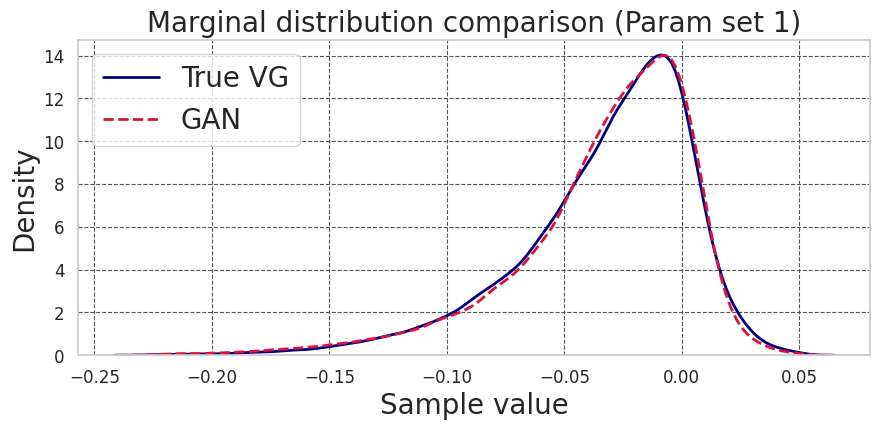


📌 Parameter set 2
    θ = 0.200   κ = 0.400   σ = 0.400   T = 0.082
    📏 Wasserstein distance: 0.0060
    🔍 Clipped to [-0.563, 1.009]


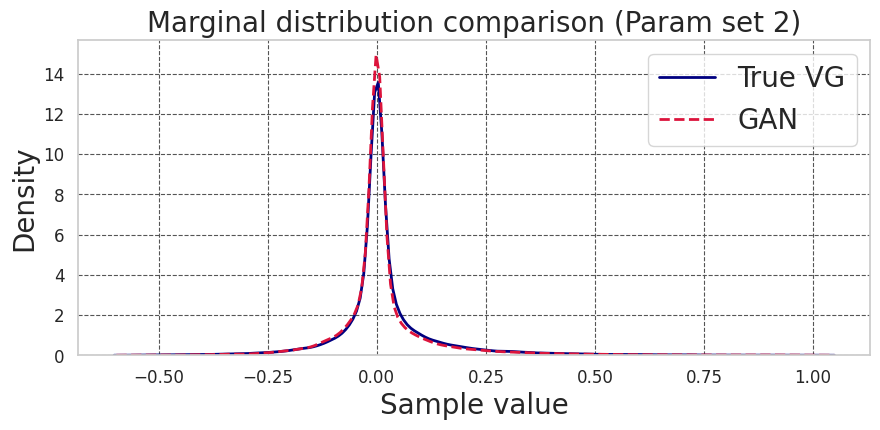


📌 Parameter set 3
    θ = -0.400   κ = 0.400   σ = 0.400   T = 0.082
    📏 Wasserstein distance: 0.0026
    🔍 Clipped to [-1.173, 0.513]


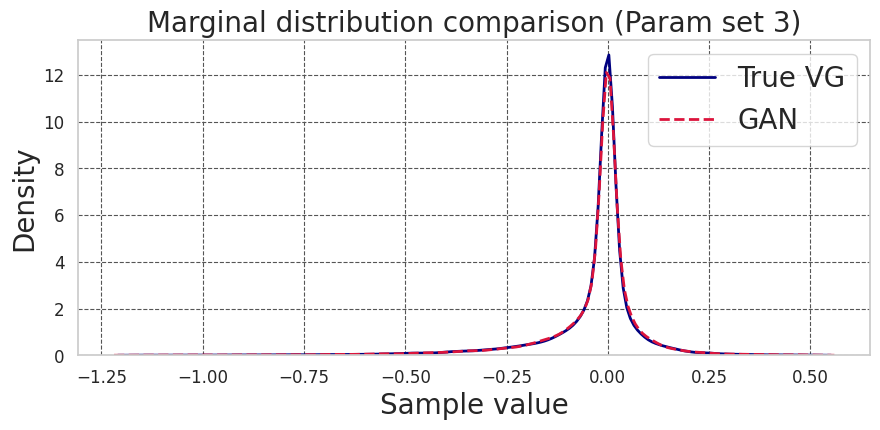


📌 Parameter set 4
    θ = 0.200   κ = 0.050   σ = 0.100   T = 0.507
    📏 Wasserstein distance: 0.0053
    🔍 Clipped to [-0.118, 0.459]


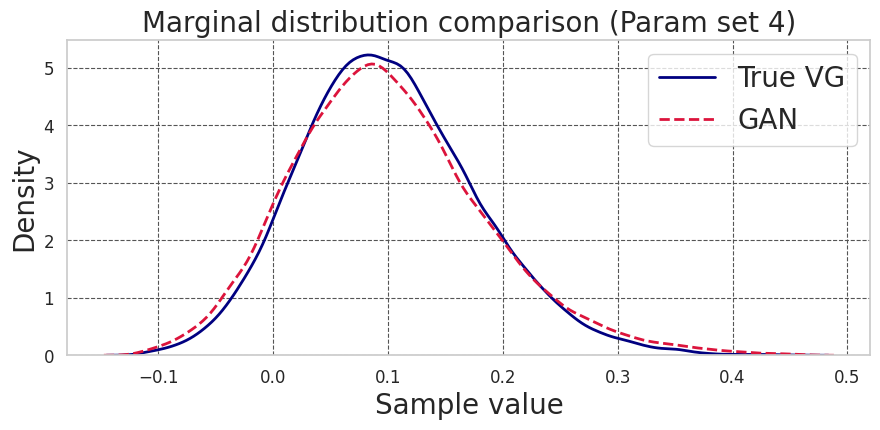


📌 Parameter set 5
    θ = 0.000   κ = 0.050   σ = 0.400   T = 0.507
    📏 Wasserstein distance: 0.0016
    🔍 Clipped to [-0.945, 0.925]


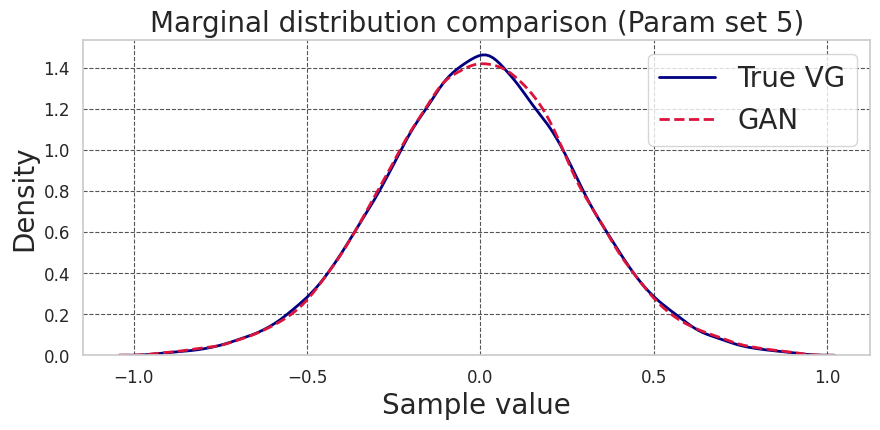


📌 Parameter set 6
    θ = 0.200   κ = 0.400   σ = 0.100   T = 0.507
    📏 Wasserstein distance: 0.0030
    🔍 Clipped to [-0.104, 0.732]


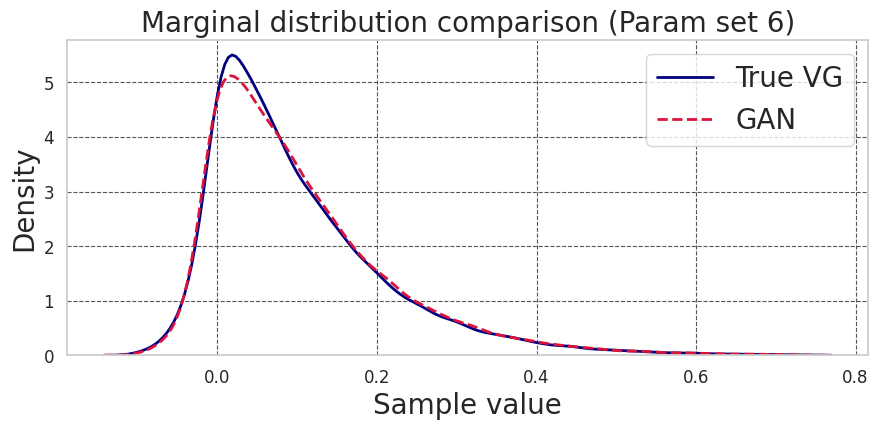


📌 Parameter set 7
    θ = -0.400   κ = 0.050   σ = 0.400   T = 0.507
    📏 Wasserstein distance: 0.0050
    🔍 Clipped to [-1.295, 0.655]


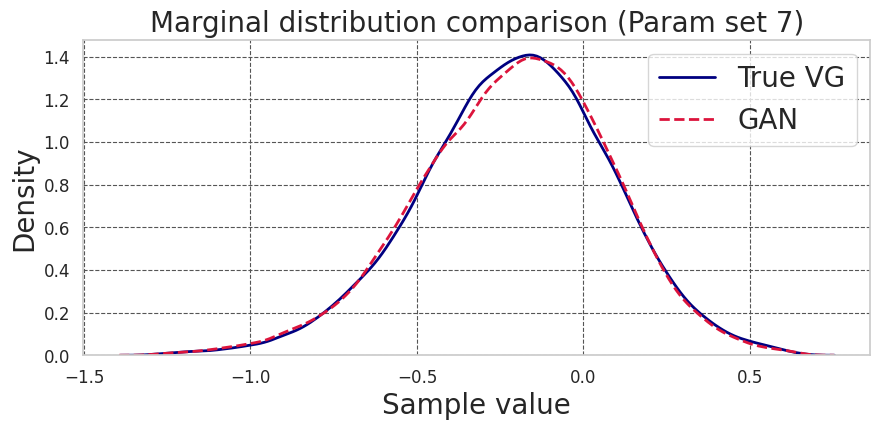

In [21]:
import torch

extreme_params = torch.tensor([
    [-0.40, 0.05, 0.1, 30/365],   
    [ 0.20, 0.4, 0.4, 30/365],   
    [-0.40, 0.4, 0.4, 30/365], 
    [ 0.20, 0.05, 0.1, 185/365],  
    [ 0.00, 0.05, 0.40, 185/365],
    [ 0.20, 0.4, 0.1, 185/365],   
    [-0.40, 0.05, 0.40, 185/365], 
], dtype=torch.float32, device=__device__)

show_marginal(model, extreme_params, device=__device__)


### Typical parameter testing

This experiment evaluates the generator on representative parameter configurations.

The typical settings are strictly chosen within the training parameter ranges and do not include any extrapolation outside the domain seen during training. They correspond to standard market regimes and are used to assess the in-domain accuracy of the learned generator $G$.



📌 Parameter set 1
    θ = -0.250   κ = 0.050   σ = 0.150   T = 0.082
    📏 Wasserstein distance: 0.0013
    🔍 Clipped to [-0.241, 0.131]


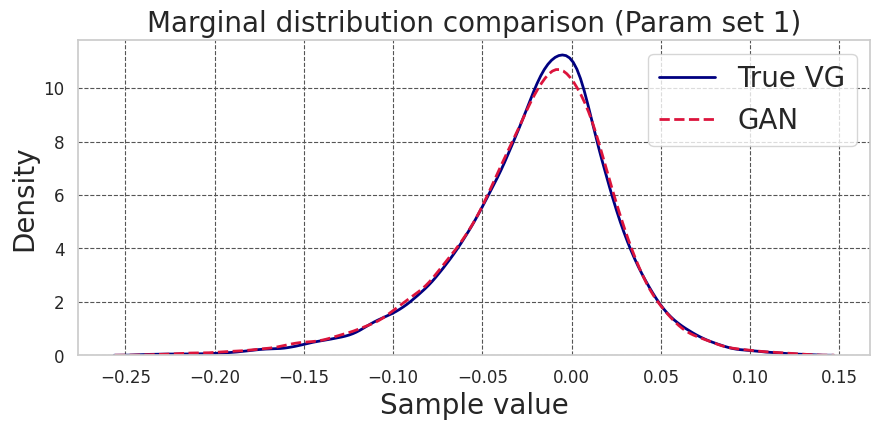


📌 Parameter set 2
    θ = -0.200   κ = 0.200   σ = 0.250   T = 0.164
    📏 Wasserstein distance: 0.0011
    🔍 Clipped to [-0.609, 0.344]


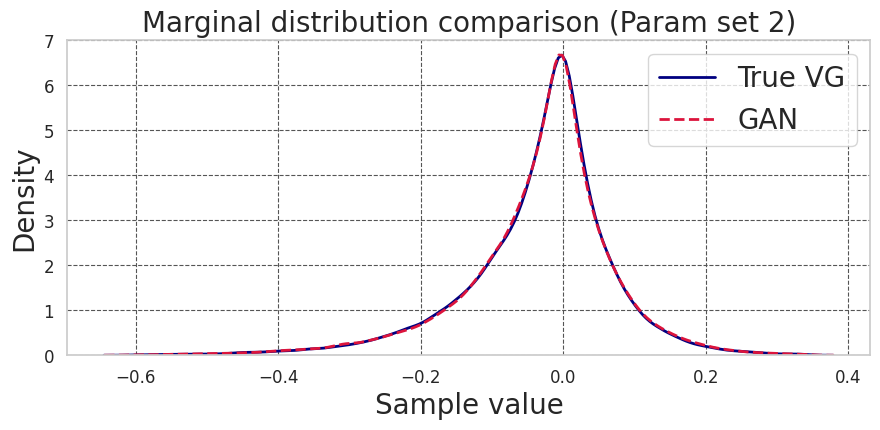


📌 Parameter set 3
    θ = -0.250   κ = 0.100   σ = 0.300   T = 0.247
    📏 Wasserstein distance: 0.0022
    🔍 Clipped to [-0.709, 0.449]


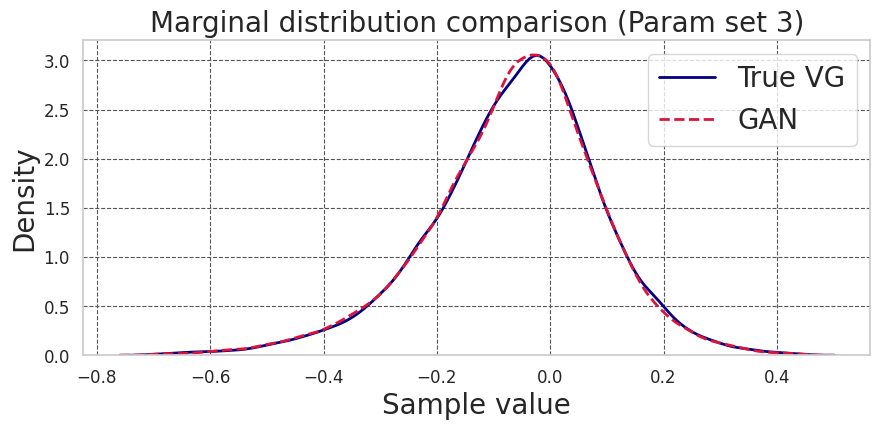


📌 Parameter set 4
    θ = 0.000   κ = 0.300   σ = 0.100   T = 0.329
    📏 Wasserstein distance: 0.0007
    🔍 Clipped to [-0.249, 0.254]


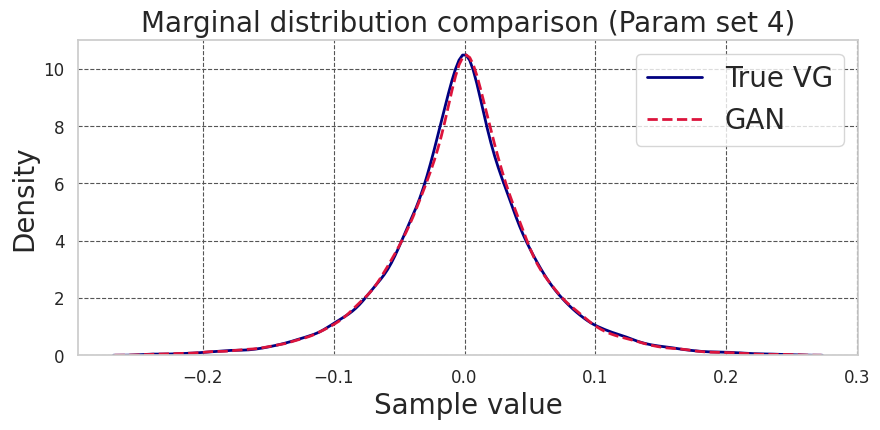


📌 Parameter set 5
    θ = 0.050   κ = 0.200   σ = 0.200   T = 0.411
    📏 Wasserstein distance: 0.0015
    🔍 Clipped to [-0.452, 0.531]


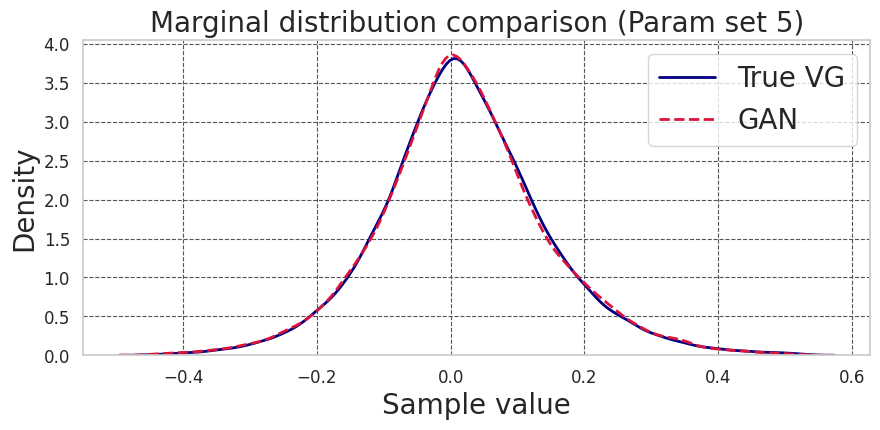


📌 Parameter set 6
    θ = -0.100   κ = 0.350   σ = 0.300   T = 0.507
    📏 Wasserstein distance: 0.0016
    🔍 Clipped to [-1.027, 0.756]


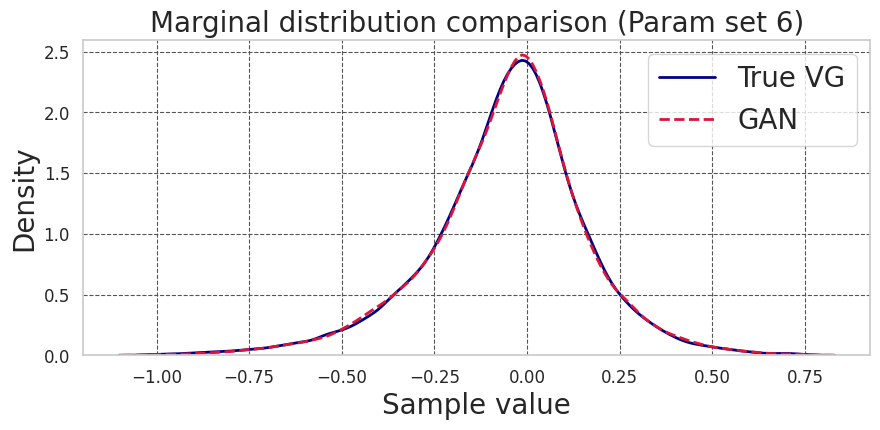

In [22]:
import torch

typical_params = torch.tensor([
    [-0.25, 0.05, 0.15, 30/365],
    [-0.20, 0.20, 0.25, 60/365],
    [-0.25, 0.10, 0.30, 90/365],
    [ 0.00, 0.30, 0.10, 120/365],
    [ 0.05, 0.20, 0.20, 150/365],
    [-0.10, 0.35, 0.30, 185/365],
], dtype=torch.float32, device=__device__)

show_marginal(model, typical_params, device=__device__)


### Pathwise test

This experiment evaluates the pathwise behavior of the generator.

The comparison is performed at several maturities $T$, allowing to assess the temporal consistency of the generated paths across the time grid.



📌 Parameter set 1 — Time T = 30/365
    θ = 0.000   κ = 0.250   σ = 0.200
    📏 Wasserstein distance: 0.0006
    🔍 Clipped to [-0.335, 0.323]


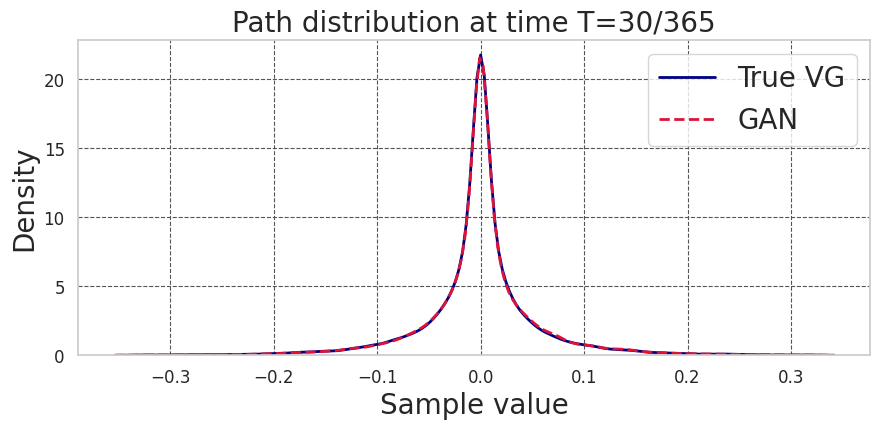


📌 Parameter set 1 — Time T = 90/365
    θ = 0.000   κ = 0.250   σ = 0.200
    📏 Wasserstein distance: 0.0008
    🔍 Clipped to [-0.445, 0.448]


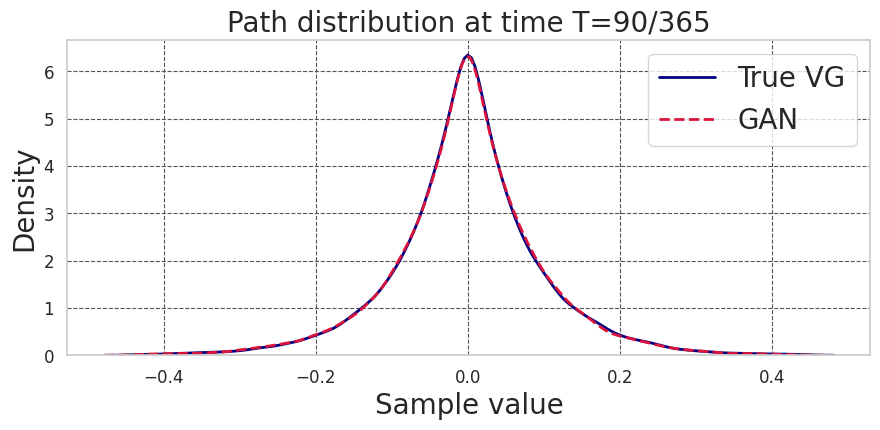


📌 Parameter set 1 — Time T = 180/365
    θ = 0.000   κ = 0.250   σ = 0.200
    📏 Wasserstein distance: 0.0010
    🔍 Clipped to [-0.560, 0.549]


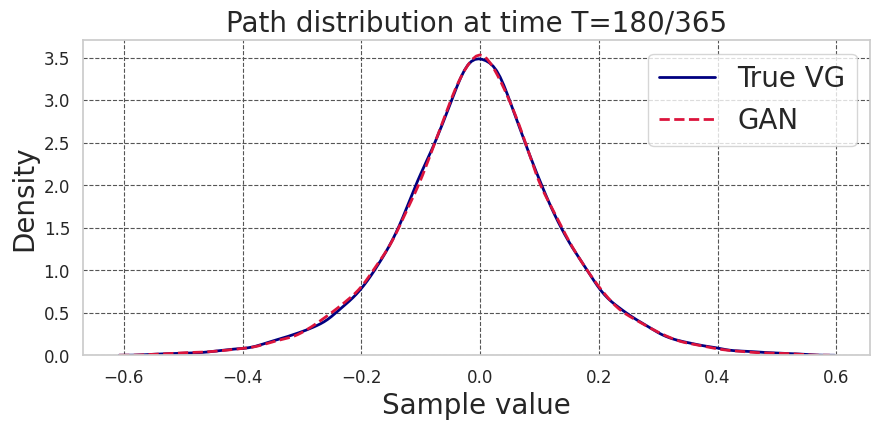


📌 Parameter set 1 — Time T = 365/365
    θ = 0.000   κ = 0.250   σ = 0.200
    📏 Wasserstein distance: 0.0023
    🔍 Clipped to [-0.727, 0.700]


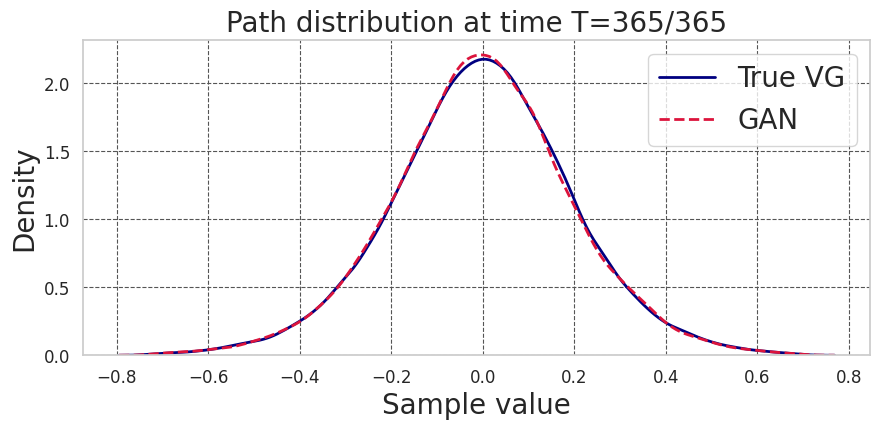

In [23]:
extreme_paths_params = torch.tensor([
    [ 0.0, 0.25, 0.2, 1.0],  
], dtype=torch.float32, device=__device__)

T = torch.tensor([30/365, 90/365, 180/365, 365/365]).to(__device__) 

show_path(model, extreme_paths_params, T, device = __device__) 

### Post-processing and distributional evaluation for the VG model

This section describes the post-processing applied to raw generator outputs and the procedure used to evaluate distributional accuracy against a reference Variance Gamma model.

---

### Martingale post-processing

The function `VG_postprocess` transforms the raw outputs of the generator into valid asset prices by enforcing the martingale condition and applying exponentiation.

The generator outputs samples interpreted as log-prices. For the Variance Gamma model, a drift correction is required to ensure that the exponential process is a martingale.

The martingale correction term is defined as

$$
\omega = -\frac{1}{\kappa} \log\!\left(1 - \kappa \theta - \tfrac{1}{2}\kappa \sigma^2\right)
$$

Given a raw generator output $X$, the corrected log-price is

$$
\tilde X = X - \omega T
$$

and the final asset price is obtained by exponentiation:

$$
S = \exp(\tilde X)
$$

This correction is applied independently for each parameter set and each trajectory.

---

### Vectorized distributional evaluation

The function `evaluate_distributional_distance_vectorized` compares the distributions generated by the model with those of a reference process over a large set of parameter configurations.

For each parameter batch and each configuration, the procedure:
- generates $N_{\text{traj}}$ samples from the reference process,
- generates $N_{\text{traj}}$ samples from the model,
- applies the same post-processing to both outputs,
- truncates extreme values to a fixed cap for numerical stability.

Let $S^{\text{true}}$ and $S^{\text{model}}$ denote the true and generated samples.

#### Moment errors

The first two moments are compared through absolute and relative errors on the mean and standard deviation:

$$
\lvert \mathbb{E}[S^{\text{model}}] - \mathbb{E}[S^{\text{true}}] \rvert,
\qquad
\frac{\lvert \mathbb{E}[S^{\text{model}}] - \mathbb{E}[S^{\text{true}}] \rvert}{\lvert \mathbb{E}[S^{\text{true}}] \rvert}
$$

and similarly for the standard deviation.

#### Distributional distances

Two distributional metrics are computed.

The 1-Wasserstein distance is approximated via sorted samples:

$$
W_1 = \frac{1}{N_{\text{traj}}} \sum_{j=1}^{N_{\text{traj}}}
\big| S^{\text{true}}_{(j)} - S^{\text{model}}_{(j)} \big|
$$

The Kolmogorov–Smirnov distance is estimated from empirical cumulative distribution functions:

$$
\mathrm{KS} = \sup_x \big| F^{\text{true}}(x) - F^{\text{model}}(x) \big|
$$

#### Aggregation

All metrics are aggregated across parameter batches, and the function reports:
- mean and standard deviation,
- worst-case errors,
- global Wasserstein and KS distances.

---

### Output

The function returns a dictionary summarizing moment errors and distributional distances, providing a comprehensive quantitative assessment of the generator’s accuracy across the parameter space.


In [24]:
def VG_postprocess(raw_output: torch.Tensor,
                    param_batch: torch.Tensor,
                    N_traj: int) -> torch.Tensor:
    """
    Apply martingale correction and exponentiation to raw GAN outputs from the VG model.

    Parameters:
    - raw_output: Tensor of shape (B * N_traj,) — the raw output of the generator (log-prices)
    - param_batch: Tensor of shape (B, 4) containing [theta, kappa, sigma, T]
    - N_traj: number of samples per parameter set

    Returns:
    - Tensor of shape (B, N_traj): the martingale-corrected outputs
    """
    B = param_batch.shape[0]
    theta = param_batch[:, 0]
    kappa = param_batch[:, 1]
    sigma = param_batch[:, 2]
    T = param_batch[:, 3]

    # Compute martingale correction omega
    arg_log = 1 - kappa * theta - 0.5 * kappa * sigma ** 2
    omega = -torch.log(arg_log) / kappa

    # Expand to match output
    omega_expanded = omega.repeat_interleave(N_traj)
    T_expanded = T.repeat_interleave(N_traj)

    # Apply correction and exponentiate
    X_adjusted = raw_output - omega_expanded * T_expanded
    return torch.exp(X_adjusted).view(B, N_traj)


        
def evaluate_distributional_distance_vectorized(model,
                                                param_tensor: torch.Tensor,
                                                N_traj: int = 10000,
                                                batch_size: int = 512,
                                                noise_size: int = 5,
                                                cap: float = 5.0,
                                                device: str = "cuda",
                                                dtype: torch.dtype = torch.float32,
                                                multi_gpu: bool = True,
                                                reference_process=None,
                                                postprocess=None,
                                                dt: float = 0.001):
    assert reference_process is not None, "A reference process must be provided."
    device = torch.device(device)
    param_tensor = param_tensor.to(dtype=dtype, device=device)
    model = model.to(device).eval()

    if multi_gpu and torch.cuda.device_count() > 1:
        model = torch.nn.DataParallel(model)

    eps = 1e-6
    N_param = param_tensor.size(0)

    # Containers
    true_means, model_means = [], []
    abs_errors, rel_errors = {k: [] for k in ["mean", "std"]}, {k: [] for k in ["mean", "std"]}
    ks_list, wass_list = [], []

    for i in range(0, N_param, batch_size):
        p_batch = param_tensor[i:i + batch_size]
        B = p_batch.size(0)

        p_expanded = p_batch.unsqueeze(1).expand(B, N_traj, -1).reshape(B * N_traj, -1)

        with torch.no_grad():
            columns = [p_batch[:, j].repeat_interleave(N_traj).to(device) for j in range(p_batch.shape[1])]
            raw_true = reference_process(*columns, dt=dt, dtype=dtype, device=device)

            if postprocess is not None:
                S_true = postprocess(raw_true.view(-1), p_batch, N_traj).clamp(1e-5, cap)
            else:
                S_true = raw_true.view(B, N_traj).clamp(1e-5, cap)

            noise = torch.rand(B * N_traj, noise_size, dtype=dtype, device=device)
            input_tensor = torch.cat([noise, p_expanded], dim=1)
            raw_output = model(input_tensor).view(B * N_traj)

            if postprocess is not None:
                S_model = postprocess(raw_output, p_batch, N_traj).clamp(1e-5, cap)
            else:
                S_model = raw_output.view(B, N_traj).clamp(1e-5, cap)

        # Moments
        true_mean = S_true.mean(dim=1)
        model_mean = S_model.mean(dim=1)
        true_std = S_true.std(dim=1)
        model_std = S_model.std(dim=1)

        # Store mean values
        true_means.append(true_mean.cpu())
        model_means.append(model_mean.cpu())

        # Absolute errors
        abs_errors["mean"].append(torch.abs(model_mean - true_mean).cpu())
        abs_errors["std"].append(torch.abs(model_std - true_std).cpu())

        # Relative errors
        rel_errors["mean"].append((torch.abs(model_mean - true_mean) / (torch.abs(true_mean) + eps)).cpu())
        rel_errors["std"].append((torch.abs(model_std - true_std) / (torch.abs(true_std) + eps)).cpu())

        # Wasserstein-1
        sorted_true, _ = torch.sort(S_true, dim=1)
        sorted_model, _ = torch.sort(S_model, dim=1)
        wass1 = torch.mean(torch.abs(sorted_true - sorted_model), dim=1)
        wass_list.append(wass1.cpu())

        # KS distance
        hist_true = torch.stack([torch.histc(x, bins=1000, min=0, max=cap) for x in S_true])
        hist_model = torch.stack([torch.histc(x, bins=1000, min=0, max=cap) for x in S_model])
        ecdf_true = torch.cumsum(hist_true, dim=1) / N_traj
        ecdf_model = torch.cumsum(hist_model, dim=1) / N_traj
        ks, _ = torch.max(torch.abs(ecdf_true - ecdf_model), dim=1)
        ks_list.append(ks.cpu())

    # Stack all collected mean values
    true_means_all = torch.cat(true_means)
    model_means_all = torch.cat(model_means)

    final = {
        "true_mean": true_means_all.mean().item(),
        "true_mean_std": true_means_all.std().item(),
        "true_mean_worst": true_means_all[torch.argmax(torch.abs(true_means_all - true_means_all.mean()))].item(),

        "model_mean": model_means_all.mean().item(),
        "model_mean_std": model_means_all.std().item(),
        "model_mean_worst": model_means_all[torch.argmax(torch.abs(model_means_all - model_means_all.mean()))].item(),
    }

    # Absolute and relative errors
    for err_type, container in zip(["abs", "rel"], [abs_errors, rel_errors]):
        for key in container:
            values = torch.cat(container[key])
            final[f"{err_type}_error_{key}_mean"] = values.mean().item()
            final[f"{err_type}_error_{key}_std"] = values.std().item()
            final[f"{err_type}_error_{key}_worst"] = values.max().item()

    # KS and Wasserstein distances
    ks_all = torch.cat(ks_list)
    wass_all = torch.cat(wass_list)
    final["ks_distance_mean"] = ks_all.mean().item()
    final["ks_distance_std"] = ks_all.std().item()
    final["ks_distance_worst"] = ks_all.max().item()

    final["wasserstein_1_mean"] = wass_all.mean().item()
    final["wasserstein_1_std"] = wass_all.std().item()
    final["wasserstein_1_worst"] = wass_all.max().item()

    return final




### Distributional evaluation over random VG parameters

This experiment evaluates the distributional accuracy of the trained generator over randomly sampled Variance Gamma parameter configurations.

A set of parameters is generated uniformly over the prescribed ranges, and for each configuration the model output is compared to the true VG distribution using moment errors and distributional distances.

The results are aggregated into a summary table reporting mean, standard deviation, and worst-case statistics across the parameter space.

---

### ⚠️ Important note on experimental scale

The results reported in the associated paper are obtained using large-scale experiments with:
- nb_simu = $100\,000$ parameter configurations,
- N_traj = $100\,000$ samples per configuration.

In this notebook, we deliberately use reduced values nb_simu = 100 and N_traj = $10\,000$ to ensure that the code can run on standard hardware within a reasonable execution time.

These reduced settings are intended **for demonstration and reproducibility purposes only** and should not be interpreted as the final quantitative results reported in the paper.


In [25]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

# Dataset parameters for VG model
params = {
    "nb_simu": 100,
    "THETAS": [-0.4, 0.2],
    "KAPPAS": [0.05, 0.4],
    "VOLS": [0.1, 0.4],
    "T": [30/365, 185/365],
    "cap": 5.0,
    "dtype": torch.float32,
    "device": torch.device("cuda")
}

# Generate random parameters
D = SUB_MODEL_param(random_param=True, **params).params

# Evaluate the model
results = evaluate_distributional_distance_vectorized(
    model, D, N_traj=10_000, batch_size=8, device="cuda",
    multi_gpu=True, reference_process=VG, postprocess=VG_postprocess
)

# Format results into table
table = []

# 1. Add true_mean and model_mean first
for base in ["true_mean", "model_mean"]:
    table.append({
        "Metric": base,
        "Mean": results[base],
        "Worst case": results.get(f"{base}_worst", None),
        "Std": results.get(f"{base}_std", None)
    })

# Skip these since they were already handled
skip_keys = [
    "true_mean", "model_mean",
    "true_mean_std", "model_mean_std",
    "true_mean_worst", "model_mean_worst"
]

# 2. Process the rest of the metrics
for metric, value in results.items():
    if metric in skip_keys:
        continue

    if metric.endswith("_mean"):
        base = metric[:-5]
        std_key = base + "_std"
        worst_key = base + "_worst"
        std_val = results.get(std_key, None)
        worst_val = results.get(worst_key, None)

        # Convert relative errors to percent
        if base.startswith("rel_error_"):
            value *= 100
            if std_val is not None:
                std_val *= 100
            if worst_val is not None:
                worst_val *= 100

        table.append({
            "Metric": base,
            "Mean": value,
            "Worst case": worst_val,
            "Std": std_val
        })

    elif any(metric.endswith(suffix) for suffix in ["_std", "_worst"]):
        continue

    else:
        table.append({
            "Metric": metric,
            "Mean": value,
            "Worst case": None,
            "Std": None
        })

# Build DataFrame
df = pd.DataFrame(table)
df = df[["Metric", "Mean", "Worst case", "Std"]]
df.set_index("Metric", inplace=True)
df = df.round(6)

# Display
print("📊 VG Model – Distributional Distance Summary (% for relative errors):")
display(
    df.style.set_caption("Variance gamma model – Moment Errors and Distances")
      .format(precision=3)
      .background_gradient(subset=["Mean"], cmap="Blues", low=0.2, high=0.6)
)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/linear.py:116: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return F.linear(input, self.weight, self.bias)


📊 VG Model – Distributional Distance Summary (% for relative errors):


,Mean,Worst case,Std
Metric,,,
true_mean,1.000,0.997,0.001
model_mean,1.000,1.005,0.002
abs_error_mean,0.002,0.006,0.001
abs_error_std,0.002,0.016,0.003
rel_error_mean,0.183,0.618,0.137
rel_error_std,1.491,8.848,1.347
ks_distance,0.012,0.025,0.004
wasserstein_1,0.003,0.007,0.001
